Nom 1: Marc Cuende

Nom 2: N/A

# Repte 3: Consum de combustible

## Definició del problema

Es vol predir el consum de combustible de diferents models de cotxes dels anys 70. Per fer-ho disposem d'un *dataset* amb diferents aspectes tècnics dels diferents models i el seu consum. Aquestes són les dades que conté:


*   Miles per Gallon (mpg): *variable contínua*
*   cylinders: *variable discreta de valors múltiples*
*   displacement: *variable contínua*
*   horsepower: *variable contínua*
*   weight: *variable contínua*
*   acceleration: *variable contínua*
*   model year: *variable discreta de valors múltiples*
*   origin: *variable categòrica*

Aquest dataset es pot descarregar de [https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data](https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data)

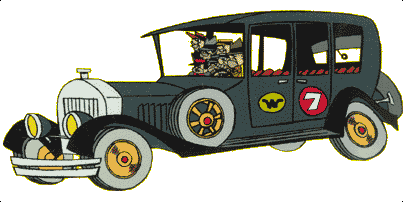

## Preparació de les dades

In [326]:
# Importa les llibreries que necessitaràs
import pandas as pd
import tensorflow as tf
import numpy as np
from urllib.request import urlretrieve
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
import random

In [327]:
# Descarrega el dataset fent servir el packet urllib de Python i guarda-ho
# amb el nom auto-mpg.data
urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data','auto-mpg.data')

('auto-mpg.data', <http.client.HTTPMessage at 0x7cc8722e91f0>)

In [328]:
# Importa el dataset descarregat com a csv, afegint els noms de les columnes i
# ajustant els paràmetres na_values, comment, sep, skipinitialspace, etc.
columns = ['displacement', 'mpg', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
mpg_data = pd.read_csv(
    "auto-mpg.data",
    header=None,
    sep='\s+', # Espais i tabulacions
    names=columns,
    na_values='?',
    skip_blank_lines=True,
    skipinitialspace=True
)

# Mostra les últimes 5 fil·les
mpg_data.tail(5)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3488451316.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+', # Espais i tabulacions


,displacement,mpg,cylinders,horsepower,weight,acceleration,model_year,origin,car_name
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger
397,31.0,4,119.0,82.0,2720.0,19.4,82,1,chevy s-10


In [329]:
# Comprova si falta algun valor a tot el conjunt de dades
np.sum(mpg_data.isna())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
displacement,0
mpg,0
cylinders,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [330]:
# No podem alimentar la xarxa neuronal amb cap valor de tipus Nan o Null, així
# que en cas de que es doni aquesta situació, eliminarem aquestes files per obtenir
# un dataset sense errors.

# Elimina les files afectades per aquests errors
mpg_data.dropna(inplace=True)

In [331]:
# La columna origin ens indica l'origen del vehicle on: 1-USA, 2-Europa, 3-Japan
# Aquesta és una variable categòrica que haurem de convertir a un vector booleà
# fent ús de la codificació one-hot encoding.
#
# Crea 3 noves columnes (USA, Europe, Japan) amb valor 1 o 0 en funció de la columna
# Origin. Pots fer servir el mètode pop() de Pandas

# Get dummies agafa tots els valors diferents d'una columna i crea columnes noves, una per cada valor diferent
mpg_data = pd.get_dummies(mpg_data, columns=['origin'])
mpg_data.rename(columns={'origin_1': 'USA', 'origin_2': 'Europe', 'origin_3': 'Japan'}, inplace=True)
mpg_data.head(5)
mpg_data.describe()

,displacement,mpg,cylinders,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [332]:
# Separa les dades per tal d'obtenir un dataset_train amb el 80% de les mostres i
# un dataset_test amb el 20%. Pots fer servir la funció sample() de Pandas. Crea també
# les variables train_labels i test_labels amb la informació de la columna 'MPG'
train_values = mpg_data.sample(frac=0.8)
test_values = mpg_data.sample(frac=0.2)
train_labels = train_values['mpg']
test_labels = test_values['mpg']

## Creació del model 1

### Pregunta 1
Quin tipus de problema és? Regressió, classificació binària o classificació múltiple? Raona la resposta

*Regressió, ja que es vol predir un valor nou partint de dades, no classificar-ne un d'existent*

### Pregunta 2
Quàntes neurones i amb quina funció d'activació haurà de tenir la capa de sortida? Raona la resposta.

*No caldrá funció d'activació, ja que no es fa servir per als problemes de regressió. Una sola neurona caldrá, per aquest mateix motiu. No hi ha capes, només la sortida*

In [333]:
# Crea una xarxa neuronal d'1 neurona anomenada model1 amb la potència (horsepower)
# com a única entrada i el consum (MPG) com a valor a predir. La funció de pèrdua
# serà la mitja de l'error absolut
model1 = Sequential()
model1.add(Dense(1, input_shape=(1,)))
model1.compile(optimizer='adam', loss='mae')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [334]:
# Entrena el model amb les dades d'entrenament
model1.fit(train_values['horsepower'], train_labels, epochs=50)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 18.3293  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.5366 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.7215 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.2165 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.8193 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.7714 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.7400 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.7157 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.3987 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.6346 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7142 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5330 
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5154 
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4008 
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4

In [335]:
# Fes una avaluació amb les dades de test

test_mae1 = model1.evaluate(test_values['horsepower'], test_labels)
print("Test accuracy of model 1:", test_mae1)
model1.summary()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8570
Test accuracy of model 1: 0.8107385635375977


Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

## Creació del model 2

In [336]:
# Crea una xarxa neuronal d'1 neurona anomenada model2 amb totes les dades (excepte MPG)
# com a entrades i el consum (MPG) com a valor a predir. La funció de pèrdua
# serà la mitja de l'error absolut
train_values2 = train_values.drop(['mpg', 'car_name'], axis=1)
model2 = Sequential()
model2.add(Dense(1, input_shape=(train_values2.shape[1],)))
model2.compile(optimizer='adam', loss='mae')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [337]:
# Entrena el model amb les dades d'entrenament
model2.fit(train_values2, train_labels, epochs=50)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 731.3896  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 692.3470 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 668.0935 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 604.3871 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 584.6307 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 569.3073 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 530.0125 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 505.5092 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 457.5775 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 427.7623 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 393.8430 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 357.0736 
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321.9691 
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 286.2102 
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [338]:
# Fes una avaluació amb les dades de test
test_values2 = test_values.drop(['mpg', 'car_name'], axis=1)
test_mae2 = model2.evaluate(test_values2, test_labels)
print("Test accuracy of model 2:", test_mae2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.0313
Test accuracy of model 2: 18.29660987854004


## Creació del model 3

In [339]:
# Mostra les principals característiques estadístiques per a cada columna i
# guarda-les a la variable train_stats de forma trasposada

train_stats = train_values2.describe().T # T trasposa les dades
print(train_stats)

              count         mean         std     min       25%      50%  \
displacement  314.0    23.482484    7.765718     9.0    17.125    22.75   
cylinders     314.0   193.998408  105.008234    68.0   105.000   145.50   
horsepower    314.0   104.729299   38.579986    46.0    76.000    92.00   
weight        314.0  2973.780255  850.705769  1613.0  2228.500  2789.50   
acceleration  314.0    15.483121    2.681221     8.0    13.825    15.50   
model_year    314.0    75.939490    3.724477    70.0    73.000    76.00   

                   75%     max  
displacement    29.375    46.6  
cylinders      265.750   455.0  
horsepower     128.000   230.0  
weight        3625.750  5140.0  
acceleration    17.000    23.7  
model_year      79.000    82.0  


### Pregunta 3
Observant les dades estadístiques, creus que és convenient normalitzar les dades? Raona la resposta.

Són rangs de dades molt variats... Algunes van de 3 a 8 i altres van de 1613 a 5140. S'haurien d'estabilitzar i normalitzar.

In [340]:
# Aquesta funció reescala les característiques en un rang de 0 a 1 (normalització)
# i les centra al 0 (estandarització) amb una desviació estàndard de 1. Aquest és
# un altre tipus de normalització que també s'utilitza sovint

def norm(x):
  return (x - train_stats['mean']) / train_stats['std']

# Aplica la funció anterior a les dades d'entrenament i de prova
numerical_cols = ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year']
train_values_normalized = norm(train_values[numerical_cols])
test_values_normalized = norm(test_values[numerical_cols])

# Les columnes USA, Europe i Japan no ens interessa normalitzar-les
train_origin_cols = train_values[['USA', 'Europe', 'Japan']]
test_origin_cols = test_values[['USA', 'Europe', 'Japan']]

# Concatenar les normalitzades amb USA, Europe i Japan
train_values3 = pd.concat([train_values_normalized, train_origin_cols], axis=1)
test_values3 = pd.concat([test_values_normalized, test_origin_cols], axis=1)

train_values3.head()

,displacement,cylinders,horsepower,weight,acceleration,model_year,USA,Europe,Japan
387,1.869437,0.647583,-0.511387,0.048454,0.565742,1.627211,True,False,False
344,1.998208,-1.028476,-1.055711,-1.291610,0.341963,1.358717,True,False,False
198,1.225581,-0.980860,-1.340833,-1.385650,0.714928,0.016246,False,False,True
235,0.324183,-0.923722,-0.770589,-0.833167,1.013299,0.284741,False,False,True
25,-1.736154,1.580844,2.858236,1.929245,-0.553151,-1.594718,True,False,False


In [341]:
# Comprova la normalització revisant les estadístiques de les dades
train_values3.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year
count,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02,3.140000e+02
mean,5.657187e-17,-4.242891e-17,7.920062e-17,-2.036587e-16,9.617219e-17,-5.282399e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.864925e+00,-1.199891e+00,-1.522274e+00,-1.599590e+00,-2.790938e+00,-1.594718e+00
25%,-8.186602e-01,-8.475374e-01,-7.446685e-01,-8.760729e-01,-6.184201e-01,-7.892358e-01
50%,-9.432278e-02,-4.618534e-01,-3.299457e-01,-2.166204e-01,6.295258e-03,1.624646e-02
75%,7.587858e-01,6.832949e-01,6.031806e-01,7.663869e-01,5.657418e-01,8.217288e-01
max,2.976868e+00,2.485535e+00,3.247039e+00,2.546380e+00,3.064603e+00,1.627211e+00


### Pregunta 4
Com podem saber que hem realitzat bé la normalització a partir de la informació estadística?

Ara tots els valors son de més o menys la mateixa mida, però els ratios continuen siguent els mateixos. Per això, podem dir que han sigut ben normalitzats.

In [342]:
# Crea una xarxa neuronal d'1 neurona anomenada model3 amb les dades normalitzades.
# La funció de pèrdua serà la mitja de l'error absolut
model3 = Sequential()
model3.add(Dense(1, input_shape=(train_values3.shape[1],)))
model3.compile(optimizer='adam', loss='mae')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [343]:
# Entrena el model amb les dades d'entrenament normalitzades
model3.fit(train_values3, train_labels, epochs=50)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5620  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5844 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.4293 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4991 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5157 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5766 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3706 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3043  
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4298 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2389 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2686 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.4859 
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.3003 
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.0843 
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1684 
Ep

In [344]:
# Fes una avaluació amb les dades de test
test_mae3 = model3.evaluate(test_values3, test_labels)
print("Test accuracy of model 3:", test_mae3)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.8492
Test accuracy of model 3: 4.794415473937988


## Creació del model 4

In [345]:
# Crea un model de xarxa neuronal de tipus Dense amb 2 capes de 64 neurones amb
# funció d'activació 'relu' i una capa de sortida
model4 = Sequential()
model4.add(Dense(64, activation='relu', input_shape=(train_values3.shape[1],)))
model4.add(Dense(64, activation='relu'))
model4.add(Dense(1)) # Capa de sortida

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [346]:
# Configura i executa l'entrenament del model. Hauràs d'escollir la funció de pèrdua
# adient en funció del tipus de problema a resoldre.
# Farem servir les mètriques 'root mean square error' i 'mean absolute error'.
# Afegeix l'hiperparàmetre validation_split=0.2 a la funció fit()
'''
MAE és més robusta quan tenim valors atípics ja que no fa servir el quadrat de
l'error mentre que MSE és més útil si volem donar més importància als errors grans.
'''
model4.compile(optimizer='adam', loss='mse', metrics=['mse', 'mae'])
model4.fit(train_values3, train_labels, validation_split=0.2, epochs=50)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 32.4329 - mae: 5.4599 - mse: 32.4329 - val_loss: 31.1271 - val_mae: 5.3117 - val_mse: 31.1271
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 26.6796 - mae: 4.8949 - mse: 26.6796 - val_loss: 25.4176 - val_mae: 4.7343 - val_mse: 25.4176
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.8714 - mae: 4.2714 - mse: 20.8714 - val_loss: 19.8965 - val_mae: 4.0974 - val_mse: 19.8965
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17.0437 - mae: 3.7527 - mse: 17.0437 - val_loss: 14.3775 - val_mae: 3.3715 - val_mse: 14.3775
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11.3153 - mae: 2.9390 - mse: 11.3153 - val_loss: 9.2331 - val_mae: 2.5754 - val_mse: 9.2331
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.5783 - mae: 2.2519 - mse: 7.5783 - val_loss: 5.2307 - val_mae: 1.8296 - val_mse: 5.2307
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7087 - mae: 1.7669 - mse: 4.7087 - val_lo

In [347]:
# Fes una avaluació del model amb les dades de test
test_mae4 = model4.evaluate(test_values3, test_labels)
print("Test accuracy of model 4:", test_mae4)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2735 - mae: 0.3814 - mse: 0.2735
Test accuracy of model 4: [0.27212169766426086, 0.27212169766426086, 0.3871156871318817]


### Pregunta 5
Quin significat tenen els números obtinguts a **mae** i **mse**? Diríes que és un error acceptable? Per què?

**MAE (Mean Absolute Error):** Promig de les diferències absolutes entre les prediccions del model i els valors reals. Indica, en termes absoluts, la magnitud mitjana dels errors del nostre model.

**MSE (Mean Squared Error):** Promig dels quadrats de les diferències entre les prediccions i els valors reals. Aquesta mètrica penalitza més els errors grans, ja que eleva al quadrat cada error. És útil per donar més importància als errors més significatius.

Aquests errors són **molt acceptables** per a aquest problema de predicció de consum de combustible (MPG). La variable `mpg` va de 3 MPG a 8 MPG

Un **MAE d'aprox 0.4 MPG** significa que, de mitjana, les prediccions del nostre model es desvien dels valors reals en menys de mig MPG. No és un error notable.

Un **MSE d'aprox 0.3 MPG** també és un valor molt baix, cosa que indica que el model no està cometent errors significativament grans de manera freqüent.

En resum, els seus errors són mínims i consistents en relació amb els valors que intenta predir.

### Pregunta 6
Quina mitja d'error absolut a obtingut cada un dels models amb les dades de test? Quin model realitza una millor predicció?

In [348]:
print("Model 1:", test_mae1)
print("Model 2:", test_mae2)
print("Model 3:", test_mae3)
print("Model 4:", test_mae4)

print("El model 4 és, amb diferència, el més efectiu i el que realitza millors prediccions. A vegades el model 1 s'entrena bé, però és pura sort. El model 4 no té pràcticament desviació notable.")

Model 1: 0.8107385635375977
Model 2: 18.29660987854004
Model 3: 4.794415473937988
Model 4: [0.27212169766426086, 0.27212169766426086, 0.3871156871318817]
El model 4 és, amb diferència, el més efectiu i el que realitza millors prediccions. A vegades el model 1 s'entrena bé, però és pura sort. El model 4 no té pràcticament desviació notable.


## Predicció

In [349]:
# Mostra la predicció de dos cotxes del dataset de test i la resposta correcta
for i in range(5):
  test_car = test_values3.iloc[i]
  real_mpg = test_labels.iloc[i]

  # Predicció
  # Transformar Series a DataFrame amb una row
  test_car_for_prediction = pd.DataFrame([test_car])

  pred_raw = model4.predict(test_car_for_prediction, verbose=0)
  pred_mpg = pred_raw[0][0] # Predicció scalar

  print("MPG real:", real_mpg)
  print("MPG predit:", pred_mpg)

MPG real: 6
MPG predit: 6.102196
MPG real: 6
MPG predit: 5.450409
MPG real: 4
MPG predit: 4.528276
MPG real: 8
MPG predit: 7.6129117
MPG real: 4
MPG predit: 3.7604017


In [350]:
# Realitza la predicció d'un suposat cotxe amb:
#   4 cilindres
#   Desplaçament 100
#   50 C.V.
#   1500 kg
#   Acceleració 10 m/s^2
#   Any 82
#   Europeu
hypothetical_car = pd.DataFrame({
    'displacement': 100.0,
    'cylinders': 4.0,
    'horsepower': 50.0,
    'weight': 1500.0,
    'acceleration': 10.0,
    'model_year': 82,
    'USA': False,
    'Europe': True,
    'Japan': False
}, index=[0])

# Normalitzem valors
hypothetical_car_normalized = norm(hypothetical_car[numerical_cols])
hypothetical_car_origin_cols = hypothetical_car[['USA', 'Europe', 'Japan']]
hypothetical_car_normalized = pd.concat([hypothetical_car_normalized, hypothetical_car_origin_cols], axis=1)

# Generem i mostrem la predicció
pred_raw = model4.predict(hypothetical_car_normalized, verbose=0)
pred_mpg = pred_raw[0][0]
print("MPG predit:", pred_mpg)

MPG predit: 8.4829445
